<a href="https://colab.research.google.com/github/UNOKOR/only-SGD/blob/main/sgd_sam_cifar100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-100 · ResNet-18 · SGD + SAM

Muon 대신 **SGD(Nesterov momentum)** 로 모든 파라미터를 학습하고, **원래 SAM**(Foret et al., 2021)으로 교란하는 노트북입니다.
데이터, 모델, 학습 스케줄, AMP, 기록 방식은 `muon_only_cifar100.ipynb`, `muon_specsam_scaled_cifar100.ipynb` 와 같아서 결과를 같은 그래프에서 비교할 수 있습니다.

| 구성 | 내용 |
|---|---|
| 모델 | ResNet-18 (CIFAR용: 3x3 stem, maxpool 없음) |
| 옵티마이저 | 모든 파라미터 SGD, lr 0.1, momentum 0.9 (Nesterov), weight decay 5e-4 |
| SAM | 원래 L2 SAM, ρ = 0.05 (BN, bias 포함 전체 파라미터를 한 벡터로 보고 교란) |
| 학습 | 200 epoch, batch 256, warmup 2 epoch 후 cosine, label smoothing 0.1, seed 42 |
| 가속 | AMP (T4는 fp16 + GradScaler, A100/L4는 bf16), channels_last |

**한 스텝의 수식**
$$g = \nabla_w L_{\mathcal B}(w_t),\qquad \varepsilon = \rho\,\frac{g}{\|g\|_2}$$
$$\tilde g = \nabla_w L_{\mathcal B}(w_t + \varepsilon)$$
$$\text{SGD: } v_t = \mu v_{t-1} + \tilde g + \lambda w_t,\quad w_{t+1} = w_t - \eta\,(\tilde g + \lambda w_t + \mu v_t)$$

- 결과는 `MyDrive/muon_sam_cifar100/runs/sgd+sam_rho0.05_e200/` 에 저장됩니다.
- `use_sam=False` 로 바꾸면 SAM 없는 SGD baseline(`sgd_e200`)이 됩니다. `sam_mode="asam"` 이면 ASAM입니다.
- SAM은 스텝마다 forward-backward를 2번 하므로 Muon 단독보다 약 2배 오래 걸립니다.

**시작 전:** 메뉴 `런타임 > 런타임 유형 변경 > 하드웨어 가속기: GPU` 를 선택하세요.


## 1. 설정
학습 설정은 모두 이 셀에서 바꿉니다.

In [ ]:
CFG = dict(
    # 실험 이름: 결과가 runs/<exp_name>/ 폴더에 따로 저장되고, 학습 곡선 셀에서 모든 실험이 함께 그려집니다.
    exp_name=None,           # None이면 설정으로 자동 생성 (예: "sgd+sam_rho0.05_e200")

    # 학습
    epochs=200,
    batch_size=256,
    num_workers=2,
    label_smoothing=0.1,
    warmup_epochs=2,
    seed=42,

    # SGD (모든 파라미터)
    lr=0.1,
    momentum=0.9,
    nesterov=True,
    weight_decay=5e-4,

    # SAM
    use_sam=True,            # False면 SAM 없이 SGD만 (baseline)
    sam_mode="l2",           # "l2": 원래 SAM | "asam": ASAM (가중치 크기에 비례한 교란)
    sam_rho=0.05,            # l2: 0.05 (CIFAR-100 ResNet 표준값) | asam: 0.5 ~ 2.0

    # 기타
    use_amp=True,
    step_log_every=20,       # N 스텝마다 L(w), L(w+ε), 업데이트 후 L 기록 (0이면 끔). 기록할 때만 forward 1회 추가
    train_subset=None,       # 빠른 확인용: 예) 5000 (None이면 전체 50,000장)
    save_to_drive=True,      # Drive의 MyDrive/muon_sam_cifar100/ 에 결과와 데이터 캐시 저장 (런타임이 끊겨도 유지)
    resume=True,             # 같은 exp_name 폴더에 last.pt가 있으면 그 epoch부터 이어서 학습
)
CFG


{'exp_name': None,
 'epochs': 200,
 'batch_size': 256,
 'num_workers': 2,
 'label_smoothing': 0.1,
 'warmup_epochs': 2,
 'seed': 42,
 'lr': 0.1,
 'momentum': 0.9,
 'nesterov': True,
 'weight_decay': 0.0005,
 'use_sam': True,
 'sam_mode': 'l2',
 'sam_rho': 0.05,
 'use_amp': True,
 'step_log_every': 20,
 'train_subset': None,
 'save_to_drive': True,
 'resume': True}

## 2. 환경 준비

In [ ]:
import math, os, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device)
if device == "cuda":
    print(torch.cuda.get_device_name(0))
else:
    print("GPU가 없습니다. 런타임 > 런타임 유형 변경에서 GPU를 선택하세요.")

# T4(sm75)는 bf16 연산이 느리므로 fp16 + GradScaler, Ampere 이상은 bf16
use_bf16 = device == "cuda" and torch.cuda.get_device_capability(0)[0] >= 8
amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
amp_enabled = CFG["use_amp"] and device == "cuda"
print("AMP:", amp_enabled, amp_dtype if amp_enabled else "")

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything(CFG["seed"])
torch.backends.cudnn.benchmark = True

import json, shutil

if CFG["save_to_drive"]:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/MyDrive/muon_sam_cifar100"
else:
    ROOT = "./muon_sam_cifar100"
RUNS_DIR = os.path.join(ROOT, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)

if not CFG["exp_name"]:
    sam_tag = {"l2": "sam", "asam": "asam"}[CFG["sam_mode"]]
    sam_name = f"+{sam_tag}_rho{CFG['sam_rho']:g}" if CFG["use_sam"] else ""
    CFG["exp_name"] = f"sgd{sam_name}_e{CFG['epochs']}"
CFG["save_dir"] = os.path.join(RUNS_DIR, CFG["exp_name"])
os.makedirs(CFG["save_dir"], exist_ok=True)
with open(os.path.join(CFG["save_dir"], "config.json"), "w") as f:
    json.dump(CFG, f, indent=2, ensure_ascii=False)
print("실험:", CFG["exp_name"], "| 저장 위치:", CFG["save_dir"])
print("기존 실험:", sorted(os.listdir(RUNS_DIR)))

torch 2.11.0+cu130 | device: cuda
Tesla T4
AMP: True torch.float16
Mounted at /content/drive
실험: sgd+sam_rho0.05_e200 | 저장 위치: /content/drive/MyDrive/muon_sam_cifar100/runs/sgd+sam_rho0.05_e200
기존 실험: ['muon+specsam-scaled_rho0.001_e120', 'muon+specsam-scaled_rho0.001_e200', 'muon_e200', 'sgd+sam_rho0.05_e200']


## 3. 데이터 (CIFAR-100)

In [ ]:
MEAN, STD = (0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)
train_tf = T.Compose([
    T.RandomCrop(32, padding=4, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

# 처음 한 번만 인터넷에서 받아 Drive(ROOT/data)에 캐시하고, 이후에는 Drive에서 로컬로 복사해 사용
LOCAL_DATA = "./data"
local_dir = os.path.join(LOCAL_DATA, "cifar-100-python")
cache_dir = os.path.join(ROOT, "data", "cifar-100-python")
if not os.path.exists(local_dir) and os.path.exists(cache_dir):
    shutil.copytree(cache_dir, local_dir)
    print("Drive 캐시에서 CIFAR-100을 불러왔습니다.")

train_set = torchvision.datasets.CIFAR100(LOCAL_DATA, train=True, download=True, transform=train_tf)
test_set = torchvision.datasets.CIFAR100(LOCAL_DATA, train=False, download=True, transform=test_tf)

if not os.path.exists(cache_dir):
    shutil.copytree(local_dir, cache_dir)
    print("CIFAR-100을 Drive에 캐시했습니다. 다음 실험부터는 다시 받지 않습니다.")
if CFG["train_subset"]:
    train_set = torch.utils.data.Subset(train_set, range(CFG["train_subset"]))

loader_kw = dict(num_workers=CFG["num_workers"], pin_memory=(device == "cuda"),
                 persistent_workers=CFG["num_workers"] > 0)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=CFG["batch_size"], shuffle=True, drop_last=True, **loader_kw)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=512, shuffle=False, **loader_kw)
print(f"train {len(train_set)} | test {len(test_set)} | steps/epoch {len(train_loader)}")

Drive 캐시에서 CIFAR-100을 불러왔습니다.
train 50000 | test 10000 | steps/epoch 195


## 4. 모델: ResNet-18 (CIFAR 변형)

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(nn.Conv2d(in_planes, planes, 1, stride, bias=False), nn.BatchNorm2d(planes))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))

class ResNet(nn.Module):
    def __init__(self, num_blocks=(2, 2, 2, 2), num_classes=100):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)   # CIFAR용 stem (maxpool 없음)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, num_blocks[0], 1)
        self.layer2 = self._make_layer(128, num_blocks[1], 2)
        self.layer3 = self._make_layer(256, num_blocks[2], 2)
        self.layer4 = self._make_layer(512, num_blocks[3], 2)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, planes, n, stride):
        layers = []
        for s in [stride] + [1] * (n - 1):
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer4(self.layer3(self.layer2(self.layer1(out))))
        out = F.adaptive_avg_pool2d(out, 1).flatten(1)
        return self.fc(out)

def resnet18(num_classes=100):
    return ResNet((2, 2, 2, 2), num_classes)

model = resnet18().to(device).to(memory_format=torch.channels_last)
print(f"params: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

params: 11.22M


## 5. 옵티마이저: SGD

Muon 노트북과 달리 모든 파라미터(conv, fc, BN, bias)를 하나의 SGD로 학습합니다.


In [ ]:
opt = torch.optim.SGD(model.parameters(), lr=CFG["lr"], momentum=CFG["momentum"],
                      nesterov=CFG["nesterov"], weight_decay=CFG["weight_decay"])
optimizers = [opt]
print(f"SGD: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M params")


SGD: 11.22M params


## 6. SAM

한 스텝의 흐름:
1. 현재 가중치 `w` 에서 forward-backward → 기울기 `g`
2. 전체 파라미터를 한 벡터로 보고 `ε = ρ·g/‖g‖₂` 만큼 이동 (ASAM은 `ε = ρ·w²·g/‖w·g‖₂`)
3. 교란된 지점에서 다시 forward-backward → 기울기 `g̃`
4. `w` 로 되돌린 뒤 `g̃` 로 SGD 업데이트

fp16 GradScaler를 쓰면 기울기가 스케일되어 있으므로 `‖g‖₂` 를 구할 때 스케일을 되돌립니다.
두 번째 forward에서는 BatchNorm running 통계를 갱신하지 않습니다.


In [ ]:
class SAM:
    def __init__(self, params, mode="l2", rho=0.05):
        assert mode in ("l2", "asam"), mode
        self.params = [p for p in params if p.requires_grad]
        self.mode, self.rho = mode, rho
        self.e_w = {}

    @torch.no_grad()
    def _l2_perturb(self, params, rho, adaptive, grad_scale):
        # 원래 SAM / ASAM: params 전체를 한 벡터로 본 L2 노름 공 위의 교란
        norms = [((p.abs() if adaptive else 1.0) * p.grad).norm(2) for p in params]
        grad_norm = torch.stack(norms).norm(2) / grad_scale
        scale = rho / (grad_norm + 1e-12) / grad_scale
        for p in params:
            e_w = (p.pow(2) if adaptive else 1.0) * p.grad * scale
            p.add_(e_w)
            self.e_w[p] = e_w

    @torch.no_grad()
    def perturb(self, grad_scale=1.0):
        # grad_scale: GradScaler로 스케일된 기울기를 원래 크기로 되돌리기 위한 값
        self.e_w = {}
        params = [p for p in self.params if p.grad is not None]
        if not params:
            return False
        if not torch.isfinite(torch.stack([p.grad.norm() for p in params]).sum()):
            return False   # fp16 overflow → 이번 스텝은 교란 생략
        self._l2_perturb(params, self.rho, self.mode == "asam", grad_scale)
        return True

    @torch.no_grad()
    def restore(self):
        for p, e_w in self.e_w.items():
            p.sub_(e_w)
        self.e_w = {}

def set_bn_momentum(model, enable):
    for m in model.modules():
        if isinstance(m, nn.modules.batchnorm._BatchNorm):
            if enable:
                m.momentum = getattr(m, "_backup_momentum", m.momentum)
            else:
                m._backup_momentum = m.momentum
                m.momentum = 0.0

sam = SAM(model.parameters(), mode=CFG["sam_mode"], rho=CFG["sam_rho"]) if CFG["use_sam"] else None
print("SAM:", f'{CFG["sam_mode"]}, rho={CFG["sam_rho"]}' if sam is not None else "사용 안 함")


SAM: l2, rho=0.05


## 7. 학습 루프

In [ ]:
epochs = CFG["epochs"]
steps_per_epoch = len(train_loader)
total_steps = epochs * steps_per_epoch
warmup_steps = CFG["warmup_epochs"] * steps_per_epoch

def lr_factor(step):   # linear warmup → cosine decay
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

schedulers = [torch.optim.lr_scheduler.LambdaLR(o, lr_factor) for o in optimizers]
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled and amp_dtype == torch.float16)
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

def forward_loss(x, y):
    with torch.autocast(device_type=device, dtype=amp_dtype, enabled=amp_enabled):
        out = model(x)
        loss = criterion(out, y)
    return loss, out

def zero_grad():
    for o in optimizers:
        o.zero_grad(set_to_none=True)

def train_step(x, y):
    loss_adv = None
    zero_grad()
    loss, out = forward_loss(x, y)
    scaler.scale(loss).backward()

    if sam is not None:
        # 1) w → w + e(w)
        sam.perturb(grad_scale=scaler.get_scale() if scaler.is_enabled() else 1.0)
        zero_grad()
        # 2) 교란된 지점에서 기울기 계산 (BN 통계는 갱신하지 않음)
        set_bn_momentum(model, False)
        loss_adv, _ = forward_loss(x, y)
        scaler.scale(loss_adv).backward()
        set_bn_momentum(model, True)
        # 3) w 로 복원
        sam.restore()

    # 4) SGD 업데이트
    for o in optimizers:
        scaler.step(o)
    scaler.update()
    for s in schedulers:
        s.step()
    return loss.detach(), out.detach(), (loss_adv.detach() if loss_adv is not None else None)

@torch.no_grad()
def loss_on_batch(x, y):
    # 업데이트 직후 같은 배치의 loss (train 모드, BN 통계는 갱신하지 않음)
    set_bn_momentum(model, False)
    loss, _ = forward_loss(x, y)
    set_bn_momentum(model, True)
    return loss

@torch.no_grad()
def evaluate():
    model.eval()
    correct1 = correct5 = total = 0
    loss_sum = 0.0
    for x, y in test_loader:
        x = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        y = y.to(device, non_blocking=True)
        with torch.autocast(device_type=device, dtype=amp_dtype, enabled=amp_enabled):
            out = model(x)
        loss_sum += F.cross_entropy(out.float(), y, reduction="sum").item()
        top5 = out.topk(5, dim=1).indices
        correct1 += (top5[:, 0] == y).sum().item()
        correct5 += (top5 == y[:, None]).any(dim=1).sum().item()
        total += y.size(0)
    return loss_sum / total, 100 * correct1 / total, 100 * correct5 / total

In [ ]:
import csv

history = {k: [] for k in ["train_loss", "train_acc", "test_loss", "test_acc", "test_top5"]}
best_acc, start_epoch = 0.0, 1
last_path = os.path.join(CFG["save_dir"], "last.pt")
step_log_path = os.path.join(CFG["save_dir"], "step_log.csv")
STEP_COLS = ["step", "epoch", "lr", "loss_w", "loss_w_eps", "loss_after"]
csv_path = os.path.join(CFG["save_dir"], "history.csv")

if CFG["resume"] and os.path.exists(last_path):
    ckpt = torch.load(last_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    for o, sd in zip(optimizers, ckpt["optimizers"]):
        o.load_state_dict(sd)
    for s, sd in zip(schedulers, ckpt["schedulers"]):
        s.load_state_dict(sd)
    scaler.load_state_dict(ckpt["scaler"])
    history, best_acc, start_epoch = ckpt["history"], ckpt["best_acc"], ckpt["epoch"] + 1
    print(f"last.pt에서 이어서 학습: epoch {start_epoch}부터 (best {best_acc:.2f}%)")

for epoch in range(start_epoch, epochs + 1):
    model.train()
    t0 = time.time()
    loss_sum = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    seen = 0
    step_rows = []
    for it, (x, y) in enumerate(train_loader):
        x = x.to(device, non_blocking=True).to(memory_format=torch.channels_last)
        y = y.to(device, non_blocking=True)
        lr_now = schedulers[0].get_last_lr()[0]
        loss, out, loss_adv = train_step(x, y)
        if CFG["step_log_every"] and it % CFG["step_log_every"] == 0:
            # loss_w: 업데이트 전 L(w), loss_w_eps: SAM 교란 지점 L(w+ε), loss_after: 업데이트 후 같은 배치의 L(w')
            step_rows.append([(epoch - 1) * steps_per_epoch + it, epoch, lr_now, loss.item(),
                              loss_adv.item() if loss_adv is not None else float("nan"),
                              loss_on_batch(x, y).item()])
        loss_sum += loss.float() * y.size(0)
        correct += (out.argmax(1) == y).sum()
        seen += y.size(0)

    train_loss, train_acc = loss_sum.item() / seen, 100 * correct.item() / seen
    test_loss, test_acc, test_top5 = evaluate()
    for k, v in zip(history, [train_loss, train_acc, test_loss, test_acc, test_top5]):
        history[k].append(v)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({"model": model.state_dict(), "epoch": epoch, "acc": test_acc, "cfg": CFG},
                   os.path.join(CFG["save_dir"], "best.pt"))
    torch.save({"model": model.state_dict(), "optimizers": [o.state_dict() for o in optimizers],
                "schedulers": [s.state_dict() for s in schedulers], "scaler": scaler.state_dict(),
                "history": history, "best_acc": best_acc, "epoch": epoch, "cfg": CFG}, last_path)
    if step_rows:
        new_file = not os.path.exists(step_log_path)
        with open(step_log_path, "a", newline="") as f:
            w = csv.writer(f)
            if new_file:
                w.writerow(STEP_COLS)
            w.writerows(step_rows)
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch", *history])
        w.writerows([i + 1, *(round(history[k][i], 4) for k in history)] for i in range(len(history["train_loss"])))

    print(f"[{epoch:3d}/{epochs}] train loss {train_loss:.3f} acc {train_acc:5.2f}% | "
          f"test loss {test_loss:.3f} top1 {test_acc:5.2f}% top5 {test_top5:5.2f}% | "
          f"best {best_acc:5.2f}% | lr {schedulers[0].get_last_lr()[0]:.4f} | {time.time() - t0:.0f}s")

print(f"\n최고 test top-1 정확도: {best_acc:.2f}%")

[  1/200] train loss 3.955 acc 12.20% | test loss 3.373 top1 18.10% top5 47.26% | best 18.10% | lr 0.0503 | 42s
[  2/200] train loss 3.253 acc 26.47% | test loss 2.995 top1 26.47% top5 55.75% | best 26.47% | lr 0.1000 | 36s
[  3/200] train loss 2.770 acc 38.68% | test loss 2.219 top1 41.32% top5 74.27% | best 41.32% | lr 0.1000 | 41s
[  4/200] train loss 2.458 acc 47.52% | test loss 1.947 top1 48.01% top5 79.38% | best 48.01% | lr 0.1000 | 42s
[  5/200] train loss 2.260 acc 53.49% | test loss 1.909 top1 49.01% top5 79.81% | best 49.01% | lr 0.0999 | 40s
[  6/200] train loss 2.128 acc 57.36% | test loss 1.823 top1 51.93% top5 81.76% | best 51.93% | lr 0.0999 | 47s
[  7/200] train loss 2.014 acc 60.95% | test loss 1.667 top1 55.70% top5 84.62% | best 55.70% | lr 0.0998 | 39s
[  8/200] train loss 1.936 acc 63.50% | test loss 1.512 top1 59.30% top5 86.80% | best 59.30% | lr 0.0998 | 41s
[  9/200] train loss 1.857 acc 65.90% | test loss 1.566 top1 58.38% top5 85.91% | best 59.30% | lr 0.099

## 8. 학습 곡선 (모든 실험 비교)

`runs/` 아래 모든 실험의 `history.csv` 를 읽어 한 그래프에 겹쳐 그립니다. 실선은 test, 점선은 train, 굵은 선은 이번 실험입니다.
학습 없이 비교만 보고 싶으면 1, 2번 셀만 실행한 뒤 이 셀을 실행하세요.

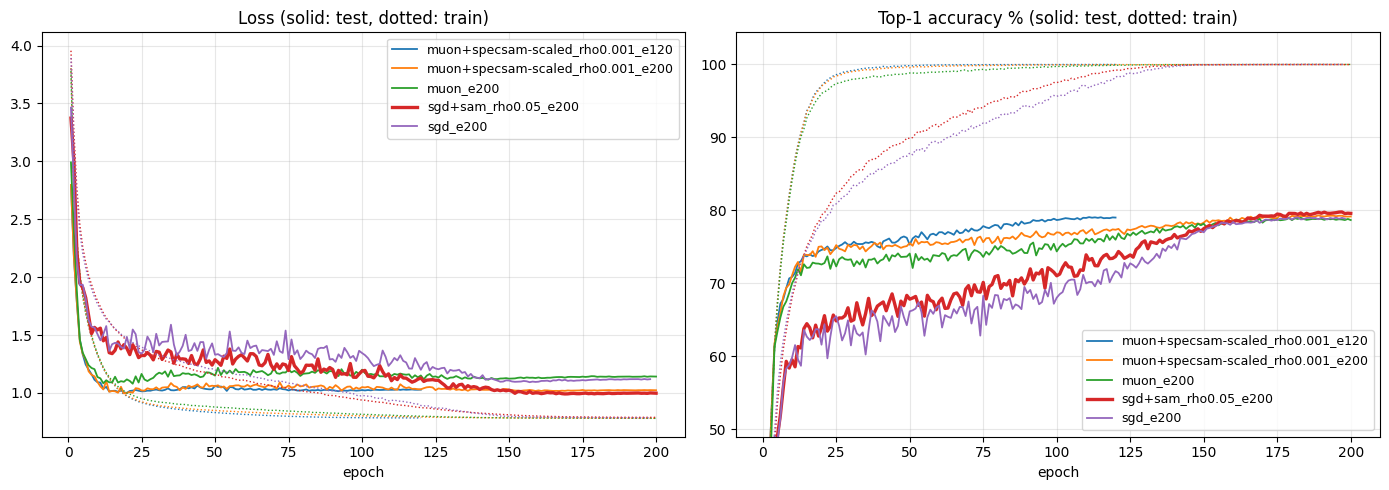

,experiment,epochs,best_top1,best_epoch,final_top1,final_top5,min_test_loss
0,sgd+sam_rho0.05_e200,200,79.77,197,79.57,94.40,0.9911
1,muon+specsam-scaled_rho0.001_e200,200,79.34,176,79.15,94.32,0.9957
2,muon+specsam-scaled_rho0.001_e120,120,79.06,111,79.00,94.47,0.9994
3,sgd_e200,198,79.02,182,78.85,94.23,1.0924
4,muon_e200,200,78.97,183,78.66,94.29,1.0791


In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

PLOT_RUNS = None   # 일부만 보려면 예: ["sgd+sam_rho0.05_e200", "muon_e200", "muon+specsam-scaled_rho0.001_e200"]

rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, path in enumerate(sorted(glob.glob(os.path.join(RUNS_DIR, "*", "history.csv")))):
    name = os.path.basename(os.path.dirname(path))
    if PLOT_RUNS and name not in PLOT_RUNS:
        continue
    h = pd.read_csv(path)
    color, lw = f"C{i % 10}", (2.4 if name == CFG["exp_name"] else 1.3)
    axes[0].plot(h.epoch, h.test_loss, color=color, lw=lw, label=name)
    axes[0].plot(h.epoch, h.train_loss, color=color, lw=1, ls=":")
    axes[1].plot(h.epoch, h.test_acc, color=color, lw=lw, label=name)
    axes[1].plot(h.epoch, h.train_acc, color=color, lw=1, ls=":")
    best = h.loc[h.test_acc.idxmax()]
    rows.append(dict(experiment=name, epochs=len(h), best_top1=best.test_acc, best_epoch=int(best.epoch),
                     final_top1=h.test_acc.iloc[-1], final_top5=h.test_top5.iloc[-1],
                     min_test_loss=h.test_loss.min()))

axes[0].set_title("Loss (solid: test, dotted: train)"); axes[0].set_xlabel("epoch")
axes[1].set_title("Top-1 accuracy % (solid: test, dotted: train)"); axes[1].set_xlabel("epoch")
axes[1].set_ylim(bottom=max(0, min((r["best_top1"] for r in rows), default=0) - 30))
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

summary = pd.DataFrame(rows).sort_values("best_top1", ascending=False).reset_index(drop=True)
summary.to_csv(os.path.join(ROOT, "summary.csv"), index=False)
summary

## 8-2. 스텝 단위 loss 분석 (SAM이 L(w)를 올리는 순간)

`step_log.csv` 에 `step_log_every` 스텝마다 기록한 값으로 그립니다.
- **loss_w**: 업데이트 전 현재 가중치의 loss L(w)
- **loss_w_eps**: SAM이 교란한 지점의 loss L(w+ε) (SAM을 안 쓰면 없음)
- **loss_after**: 업데이트 직후 **같은 배치**의 loss L(w')
- **Δ = loss_after − loss_w**: 양수면 그 스텝에서 L(w)가 **올라간** 것

위 두 그래프는 이번 실험(`ANALYZE_RUN`), 아래 그래프는 `step_log.csv` 가 있는 모든 실험의 epoch별 "L(w)가 오른 스텝 비율"을 비교합니다.

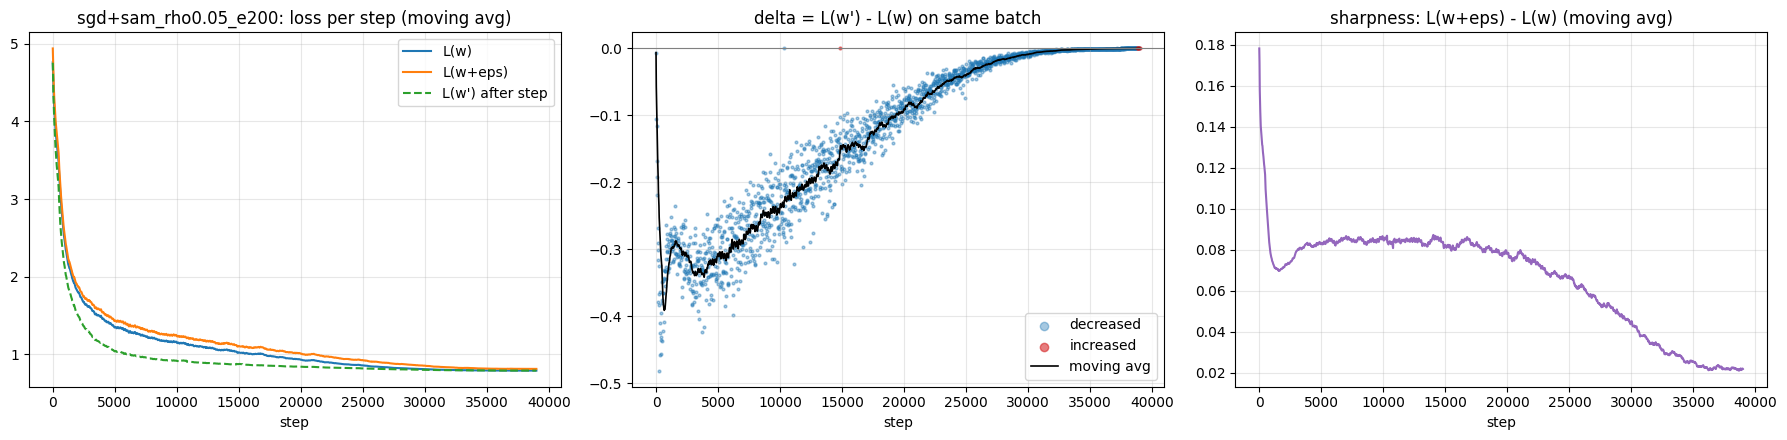

L(w)가 올라간 스텝 비율: 전체 0.4% (기록 2000개, 평균 Δ -0.1268)


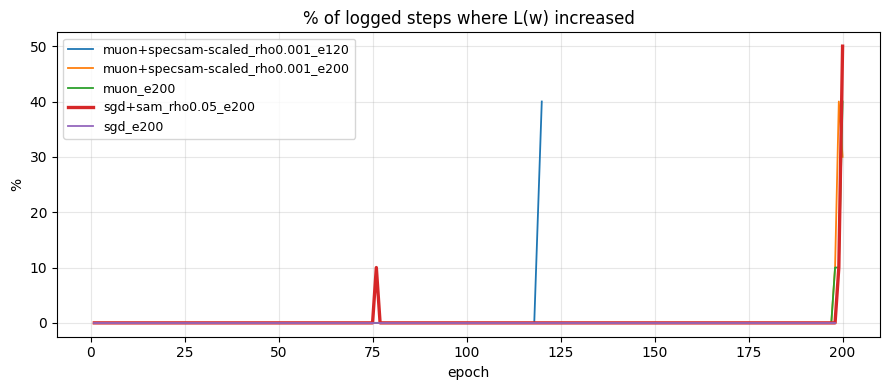

In [ ]:
ANALYZE_RUN = CFG["exp_name"]   # 다른 실험을 보려면 이름을 넣으세요
SMOOTH = 25                     # 이동 평균 창 크기 (기록 개수 기준)

def load_step_log(name):
    path = os.path.join(RUNS_DIR, name, "step_log.csv")
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path).drop_duplicates("step", keep="last").sort_values("step")
    s["delta"] = s.loss_after - s.loss_w
    s["sharp_gap"] = s.loss_w_eps - s.loss_w
    return s

s = load_step_log(ANALYZE_RUN)
if s is None:
    print(f"{ANALYZE_RUN} 에는 step_log.csv 가 없습니다 (이 기능을 넣기 전 실험이거나 step_log_every=0).")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    ax = axes[0]
    ax.plot(s.step, s.loss_w.rolling(SMOOTH, min_periods=1).mean(), label="L(w)")
    if s.loss_w_eps.notna().any():
        ax.plot(s.step, s.loss_w_eps.rolling(SMOOTH, min_periods=1).mean(), label="L(w+eps)")
    ax.plot(s.step, s.loss_after.rolling(SMOOTH, min_periods=1).mean(), label="L(w') after step", ls="--")
    ax.set_title(f"{ANALYZE_RUN}: loss per step (moving avg)"); ax.set_xlabel("step"); ax.legend()

    ax = axes[1]
    up = s.delta > 0
    ax.scatter(s.step[~up], s.delta[~up], s=4, alpha=0.4, color="C0", label="decreased")
    ax.scatter(s.step[up], s.delta[up], s=4, alpha=0.6, color="C3", label="increased")
    ax.plot(s.step, s.delta.rolling(SMOOTH, min_periods=1).mean(), color="k", lw=1.2, label="moving avg")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_title("delta = L(w') - L(w) on same batch"); ax.set_xlabel("step"); ax.legend(markerscale=3)

    ax = axes[2]
    if s.sharp_gap.notna().any():
        ax.plot(s.step, s.sharp_gap.rolling(SMOOTH, min_periods=1).mean(), color="C4")
        ax.set_title("sharpness: L(w+eps) - L(w) (moving avg)")
    else:
        ax.set_title("sharpness: SAM not used in this run")
    ax.set_xlabel("step")
    for a in axes:
        a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"L(w)가 올라간 스텝 비율: 전체 {100 * up.mean():.1f}% "
          f"(기록 {len(s)}개, 평균 Δ {s.delta.mean():+.4f})")

# 모든 실험 비교: epoch별 L(w)가 오른 스텝 비율
plt.figure(figsize=(9, 4))
for i, path in enumerate(sorted(glob.glob(os.path.join(RUNS_DIR, "*", "step_log.csv")))):
    name = os.path.basename(os.path.dirname(path))
    if PLOT_RUNS and name not in PLOT_RUNS:
        continue
    r = load_step_log(name)
    frac = r.groupby("epoch").delta.apply(lambda d: 100 * (d > 0).mean())
    plt.plot(frac.index, frac.values, color=f"C{i % 10}", lw=2.4 if name == ANALYZE_RUN else 1.3, label=name)
plt.title("% of logged steps where L(w) increased"); plt.xlabel("epoch"); plt.ylabel("%")
plt.grid(alpha=0.3); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

## 9. 저장된 최고 모델로 평가

In [ ]:
ckpt = torch.load(os.path.join(CFG["save_dir"], "best.pt"), map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
test_loss, test_acc, test_top5 = evaluate()
print(f"epoch {ckpt['epoch']} checkpoint → top-1 {test_acc:.2f}% | top-5 {test_top5:.2f}%")

epoch 197 checkpoint → top-1 79.77% | top-5 94.33%
